# Denmark SARS-CoV-2: Weekly Epidemic Summary 2021

Five figures summarizing the 2021 epidemic in Denmark by ISO epiweek (W01–W52), plus proportional subsampling of sequences:

| Figure | Description | Notes |
|--------|-------------|-------|
| **1 — True Infections** | SSI confirmed cases + modelled true infections via IAR | IAR unavailable for W52; true infections shown W01–W51 only |
| **2 — Detected Cases by Variant** | SSI confirmed cases × variant proportion from GISAID | Uses *all* Denmark GISAID sequences (no region filter) for proportions |
| **3 — GISAID Sequences by Variant** | Raw sequence counts from GISAID | Filtered to complete collection date + known Danish region |
| **4 — Sampling Proportion** | Sequences (Fig 3) ÷ detected cases (Fig 2) per variant | Fraction of detected cases that were sequenced each week |
| **5 — Subsampled Sequences** | Sequences after proportional downsampling | Solid = subsampled, faded = original for comparison |

### Subsampling strategy

Each variant is downsampled independently within its epiweek window to a target sampling-proportion baseline. If a week's observed proportion exceeds the baseline, sequences are randomly downsampled; otherwise all are kept.

| Variant | Epiweek window | Baseline |
|---------|---------------|----------|
| Alpha | W01–W22 | 8% |
| Delta | W23–W35 | 12% |
| Omicron | W45–W52 | 4% |

### Data sources

- **SSI confirmed cases**: `sars_cov2_290k_denmark-main/growth_rates/data/03_bekraeftede_tilfaelde_doede_indlagte_pr_dag_pr_koen.csv`
- **IAR estimates**: `sars_cov2_290k_denmark-main/clade_characterization/data/IAR_denmark_data.csv`
- **GISAID sequences**: `GISAID_metadata_2026_03_08/metadata.db` (SQLite)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
import os

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# ── Paths ──
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('denmark_epiweek_summary.ipynb'))
DATA_ROOT = '/Users/lukelyu/Desktop/sars_cov2_290k_denmark-main'
GISAID_DB = '/Users/lukelyu/Desktop/GISAID_metadata_2026_03_08/metadata.db'

REGIONS = ['Hovedstaden', 'Midtjylland', 'Syddanmark', 'Sjaelland', 'Nordjylland']
VARIANTS = ['Alpha', 'Delta', 'Omicron']
VARIANT_COLORS = {'Alpha': '#2196F3', 'Delta': '#FF9800', 'Omicron': '#9C27B0'}
DATE_START, DATE_END = '2021-01-04', '2022-01-02'


# ── Helpers ──

def to_epiweek(dates):
    """Convert datetime Series or DatetimeIndex to ISO epiweek labels like '2021-W01'."""
    iso = dates.dt.isocalendar() if hasattr(dates, 'dt') else dates.isocalendar()
    return iso.year.astype(str) + '-W' + iso.week.astype(str).str.zfill(2)


def add_month_labels(ax, week_starts):
    """Add vertical month-boundary lines and centered month labels."""
    months, positions = [], []
    for i, dt in enumerate(week_starts):
        m = dt.strftime('%b')
        if not months or m != months[-1]:
            positions.append(i)
            months.append(m)
    for idx, (pos, label) in enumerate(zip(positions, months)):
        ax.axvline(x=pos - 0.5, color='gray', ls='--', alpha=0.3, lw=0.8)
        nxt = positions[idx + 1] if idx + 1 < len(positions) else len(week_starts)
        ax.text((pos + nxt) / 2, ax.get_ylim()[1] * 0.95, label,
                fontsize=10, fontweight='bold', ha='center', va='top', color='gray')


def style_weekly_ax(ax, labels, ylabel, title):
    """Apply common formatting to a weekly bar-chart axis."""
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90, fontsize=7)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontweight='bold', fontsize=13)


def plot_stacked_bars(ax, weekly_df, variants, colors, alpha=0.85):
    """Plot a stacked bar chart of variant columns onto ax. Returns x array."""
    x = np.arange(len(weekly_df))
    bottom = np.zeros(len(weekly_df))
    for v in variants:
        vals = weekly_df[v].values.astype(float)
        ax.bar(x, vals, bottom=bottom, color=colors[v], label=v, alpha=alpha)
        bottom += vals
    return x


def save_and_show(fig, filename):
    """tight_layout + save + show."""
    fig.tight_layout()
    fig.savefig(f'{NOTEBOOK_DIR}/{filename}', dpi=150, bbox_inches='tight')
    plt.show()

In [2]:
# ── SSI Confirmed Cases (W01–W52) ──

cases_raw = pd.read_csv(
    f'{DATA_ROOT}/growth_rates/data/03_bekraeftede_tilfaelde_doede_indlagte_pr_dag_pr_koen.csv',
    sep=';', encoding='latin-1')
date_col, case_col = cases_raw.columns[2], cases_raw.columns[4]
cases_raw[date_col] = pd.to_datetime(cases_raw[date_col])
cases_raw[case_col] = pd.to_numeric(cases_raw[case_col], errors='coerce')

daily_cases = cases_raw.groupby(date_col)[case_col].sum().rename('cases')
daily_cases.index.name = 'date'

# Aggregate to epiweeks, keep only complete 7-day weeks
cases_2021 = daily_cases.loc[DATE_START:DATE_END].to_frame()
cases_2021['epiweek'] = to_epiweek(cases_2021.index)
w2021 = (cases_2021.groupby('epiweek')
         .agg(week_start=('cases', lambda x: x.index.min()),
              cases=('cases', 'sum'),
              days=('cases', 'count'))
         .query('days == 7')
         .sort_values('week_start')
         .drop(columns='days'))

# ── IAR Estimates (W01–W51; data ends Dec 31 → W52 excluded) ──

iar_df = pd.read_csv(f'{DATA_ROOT}/clade_characterization/data/IAR_denmark_data.csv',
                      parse_dates=['date'], usecols=['date', 'iar']).set_index('date')

merged = pd.DataFrame({'cases': daily_cases, 'iar': iar_df['iar']}).dropna()
merged['true_inf'] = merged['cases'] / merged['iar']
merged['epiweek'] = to_epiweek(merged.index)

w_iar = (merged.groupby('epiweek')
         .agg(iar_mean=('iar', 'mean'), true_inf=('true_inf', 'sum'), days=('cases', 'count'))
         .query('days == 7')
         .drop(columns='days'))

w2021[['iar_mean', 'true_inf']] = w_iar.reindex(w2021.index)[['iar_mean', 'true_inf']]

# ── GISAID Sequences ──

VARIANT_SQL = """
    CASE WHEN Variant LIKE '%Alpha%'   THEN 'Alpha'
         WHEN Variant LIKE '%Delta%'   THEN 'Delta'
         WHEN Variant LIKE '%Omicron%' THEN 'Omicron'
         ELSE 'Other' END AS variant"""

BASE_WHERE = """
    WHERE Location LIKE '%Denmark%'
      AND "Collection date" LIKE '____-__-__'
      AND "Collection date" BETWEEN '2021-01-01' AND '2022-01-02'"""

region_clause = ' OR '.join(f'Location LIKE "%{r}%"' for r in REGIONS)

with sqlite3.connect(GISAID_DB) as conn:
    # All Denmark sequences (variant proportions for Fig 2)
    seq_all = pd.read_sql_query(
        f'SELECT "Collection date" AS date, {VARIANT_SQL} FROM metadata {BASE_WHERE}', conn)
    # Region-filtered sequences with full columns (Fig 3+ and subsampling)
    seq_records = pd.read_sql_query(f"""
        SELECT "Accession ID" AS accession_id,
               "Virus name" AS virus_name,
               "Collection date" AS date,
               "Pango lineage" AS lineage,
               {VARIANT_SQL}
        FROM metadata
        {BASE_WHERE} AND ({region_clause})
    """, conn)

seq_records['date'] = pd.to_datetime(seq_records['date'])
seq_records['epiweek'] = to_epiweek(seq_records['date'])

# Derive the date+variant view previously fetched as a separate query
seq_region = seq_records[['date', 'variant']].copy()


def pivot_to_weekly(df):
    """Pivot a sequence DataFrame to epiweek × variant counts, aligned to w2021."""
    df = df.copy()
    if not pd.api.types.is_datetime64_any_dtype(df['date']):
        df['date'] = pd.to_datetime(df['date'])
    if 'epiweek' not in df.columns:
        df['epiweek'] = to_epiweek(df['date'])
    weekly = (df.groupby(['epiweek', 'variant']).size().unstack(fill_value=0)
              .reindex(columns=VARIANTS + ['Other'], fill_value=0)
              .reindex(w2021.index, fill_value=0))
    weekly['week_start'] = w2021['week_start']
    return weekly


seq_all_wk = pivot_to_weekly(seq_all)
seq_region_wk = pivot_to_weekly(seq_region)

print(f'2021: {len(w2021)} weeks (W01–W52)')
print(f'  Confirmed cases:         {w2021["cases"].sum():>10,.0f}')
print(f'  True infections (W01–51):{w2021["true_inf"].sum():>10,.0f}')
print(f'  GISAID all Denmark:      {seq_all_wk[VARIANTS + ["Other"]].sum().sum():>10,.0f}')
print(f'  GISAID with region:      {seq_region_wk[VARIANTS + ["Other"]].sum().sum():>10,.0f}')

2021: 52 weeks (W01–W52)
  Confirmed cases:            678,611
  True infections (W01–51): 2,329,885
  GISAID all Denmark:         267,608
  GISAID with region:         260,234


## Data Exploration

Four figures progressively drilling into the 2021 epidemic:

1. **True Infections** — confirmed cases vs IAR-modelled true infections
2. **Detected Cases by Variant** — confirmed cases split by GISAID variant proportions
3. **GISAID Sequences by Variant** — region-filtered raw sequence counts (basis for subsampling)
4. **Sampling Proportion** — what fraction of detected cases were sequenced per variant per week

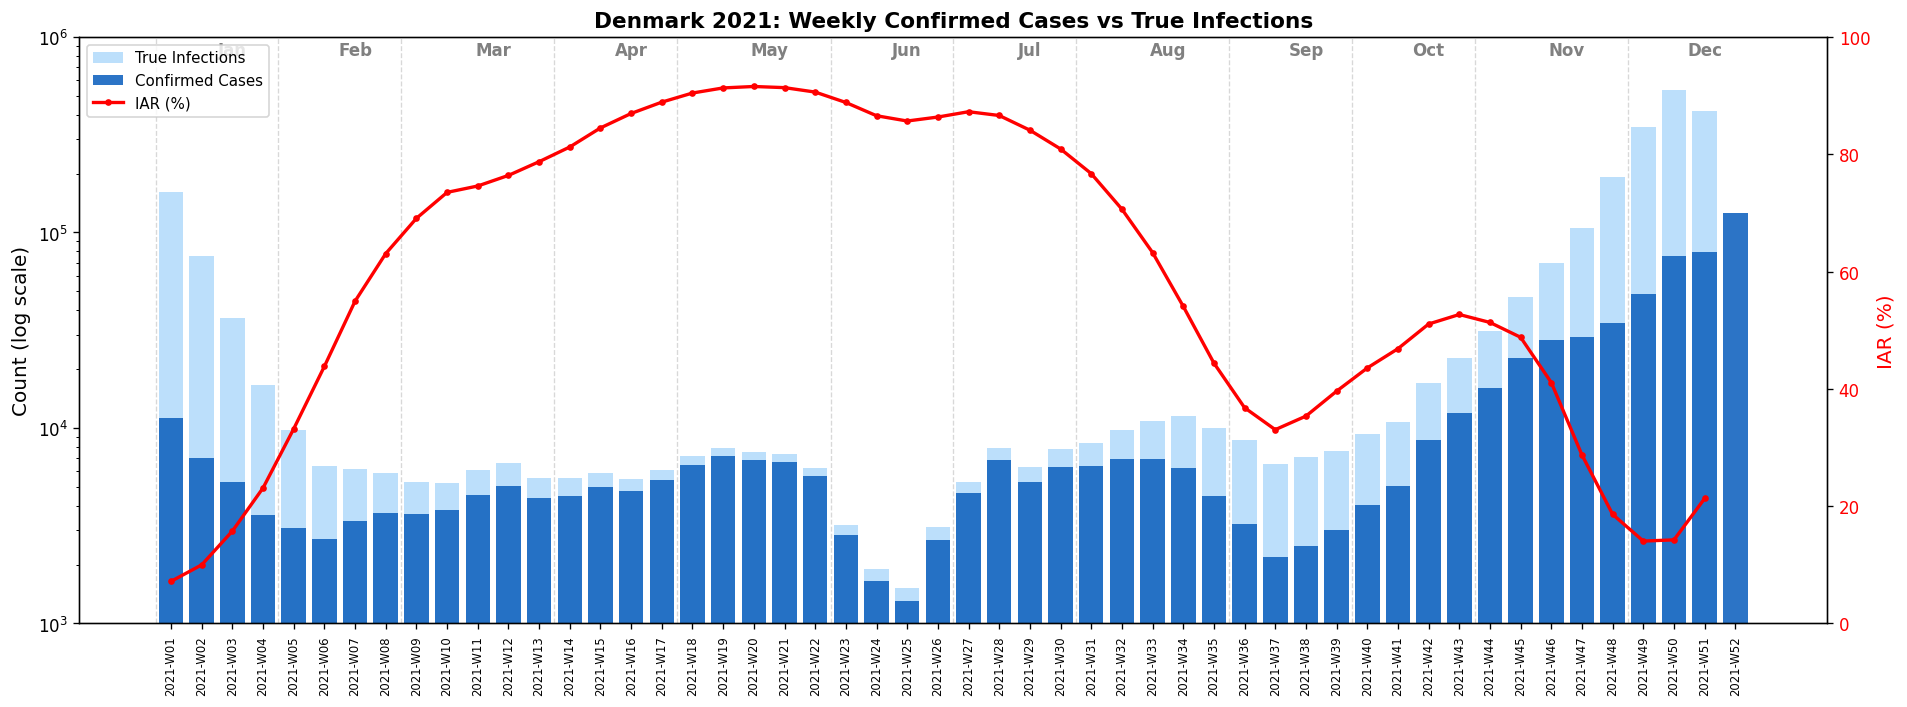

In [3]:
# ── Figure 1: Weekly Confirmed Cases vs True Infections ──

fig, ax = plt.subplots(figsize=(16, 6))
x = range(len(w2021))

true_inf = np.where(np.isnan(w2021['true_inf']), 0, w2021['true_inf'])
ax.bar(x, true_inf, color='#90CAF9', alpha=0.6, label='True Infections')
ax.bar(x, w2021['cases'], color='#1565C0', alpha=0.9, label='Confirmed Cases')

# IAR overlay (W01–W51 only)
ax2 = ax.twinx()
iar_mask = w2021['iar_mean'].notna()
ax2.plot(np.where(iar_mask)[0], w2021.loc[iar_mask, 'iar_mean'] * 100,
         color='red', marker='o', ms=3, lw=2, label='IAR (%)')
ax2.set_ylabel('IAR (%)', color='red', fontsize=12)
ax2.set_ylim(0, 100)
ax2.tick_params(axis='y', labelcolor='red')

ax.set_yscale('log')
ax.set_ylim(1e3, 1e6)
style_weekly_ax(ax, w2021.index, 'Count (log scale)',
                'Denmark 2021: Weekly Confirmed Cases vs True Infections')
add_month_labels(ax, w2021['week_start'])

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='upper left', fontsize=9)

save_and_show(fig, 'denmark_2021_weekly_true_infections.png')

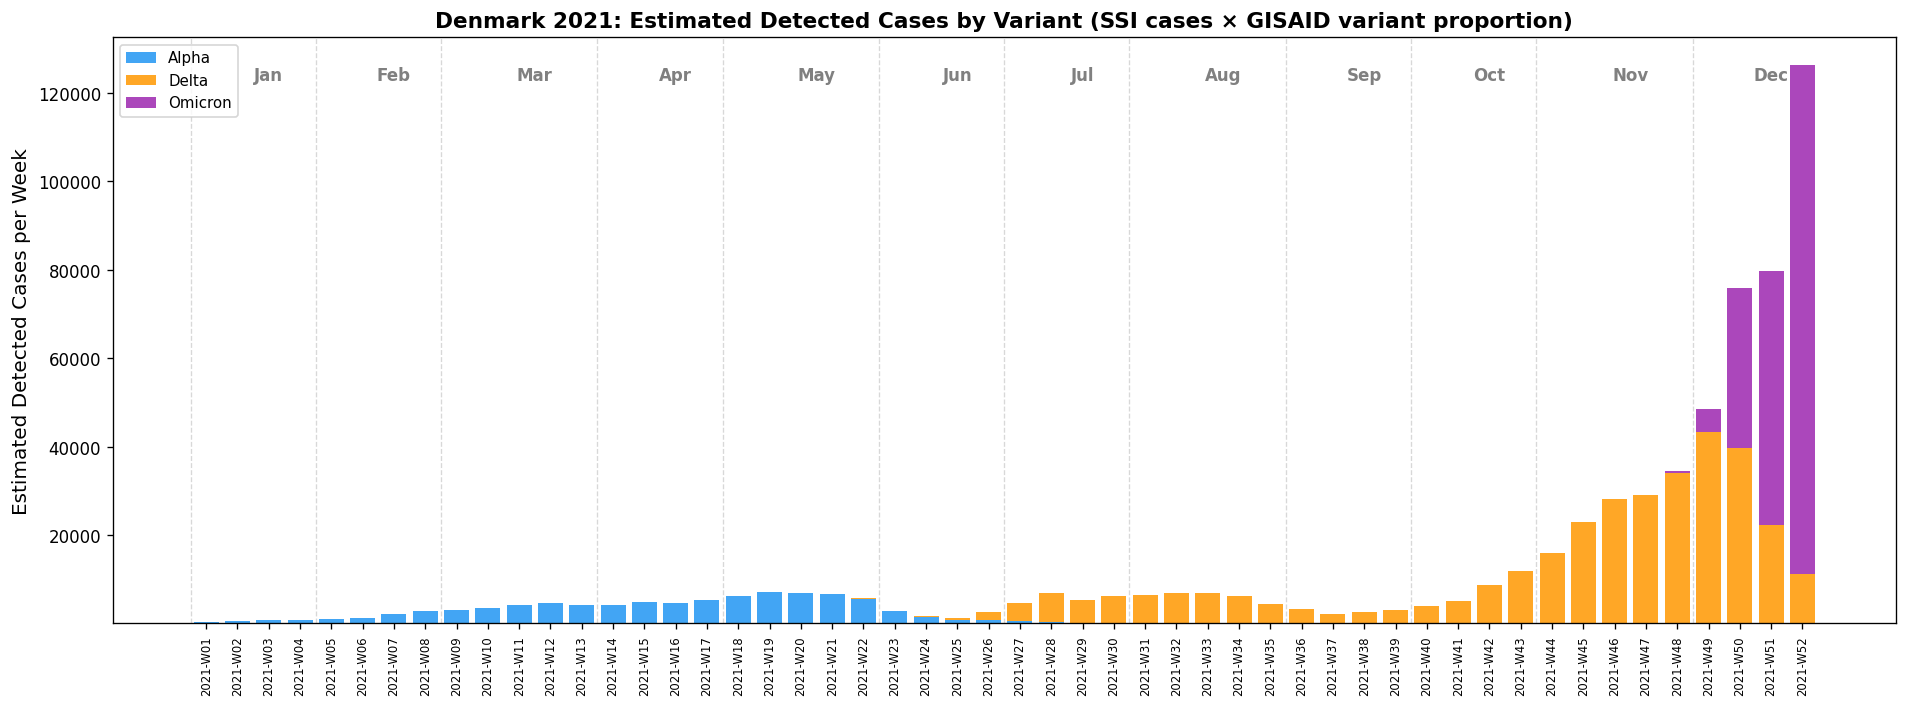

In [4]:
# ── Figure 2: Estimated Detected Cases by Variant ──

total_seq = seq_all_wk[VARIANTS + ['Other']].sum(axis=1)
variant_prop = seq_all_wk[VARIANTS].div(total_seq.replace(0, np.nan), axis=0).fillna(0)
variant_detected = variant_prop.mul(w2021['cases'], axis=0)

fig, ax = plt.subplots(figsize=(16, 6))
plot_stacked_bars(ax, variant_detected, VARIANTS, VARIANT_COLORS)

style_weekly_ax(ax, variant_detected.index, 'Estimated Detected Cases per Week',
                'Denmark 2021: Estimated Detected Cases by Variant (SSI cases × GISAID variant proportion)')
ax.legend(loc='upper left', fontsize=9)
add_month_labels(ax, w2021['week_start'])

save_and_show(fig, 'denmark_2021_weekly_detected_by_variant.png')

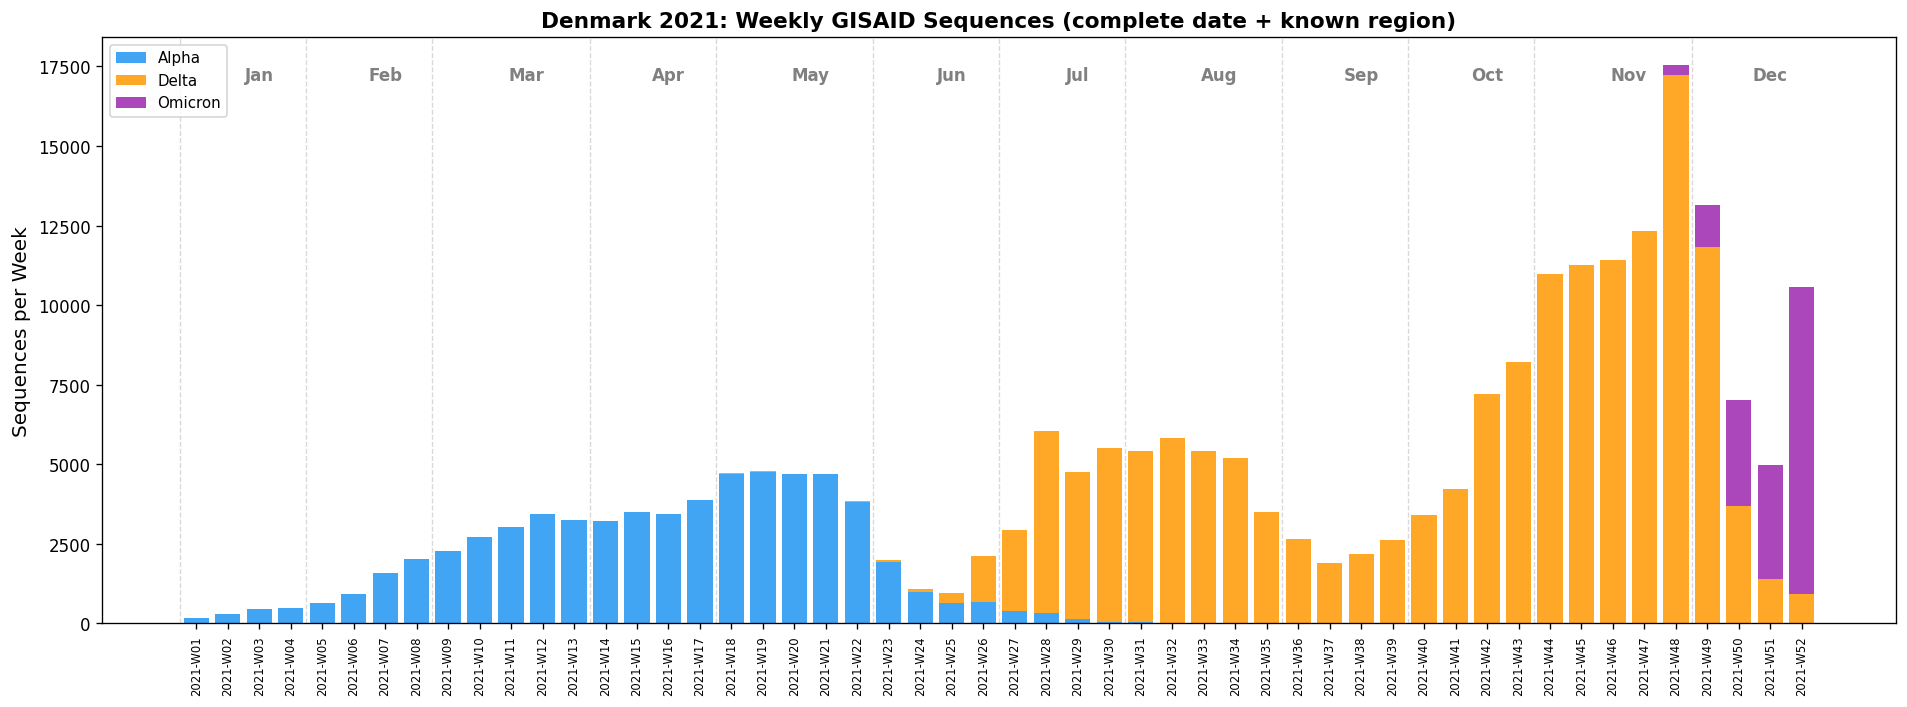

In [5]:
# ── Figure 3: GISAID Sequences by Variant ──

fig, ax = plt.subplots(figsize=(16, 6))
plot_stacked_bars(ax, seq_region_wk, VARIANTS, VARIANT_COLORS)

style_weekly_ax(ax, seq_region_wk.index, 'Sequences per Week',
                'Denmark 2021: Weekly GISAID Sequences (complete date + known region)')
ax.legend(loc='upper left', fontsize=9)
add_month_labels(ax, seq_region_wk['week_start'])

save_and_show(fig, 'denmark_2021_weekly_sequences.png')

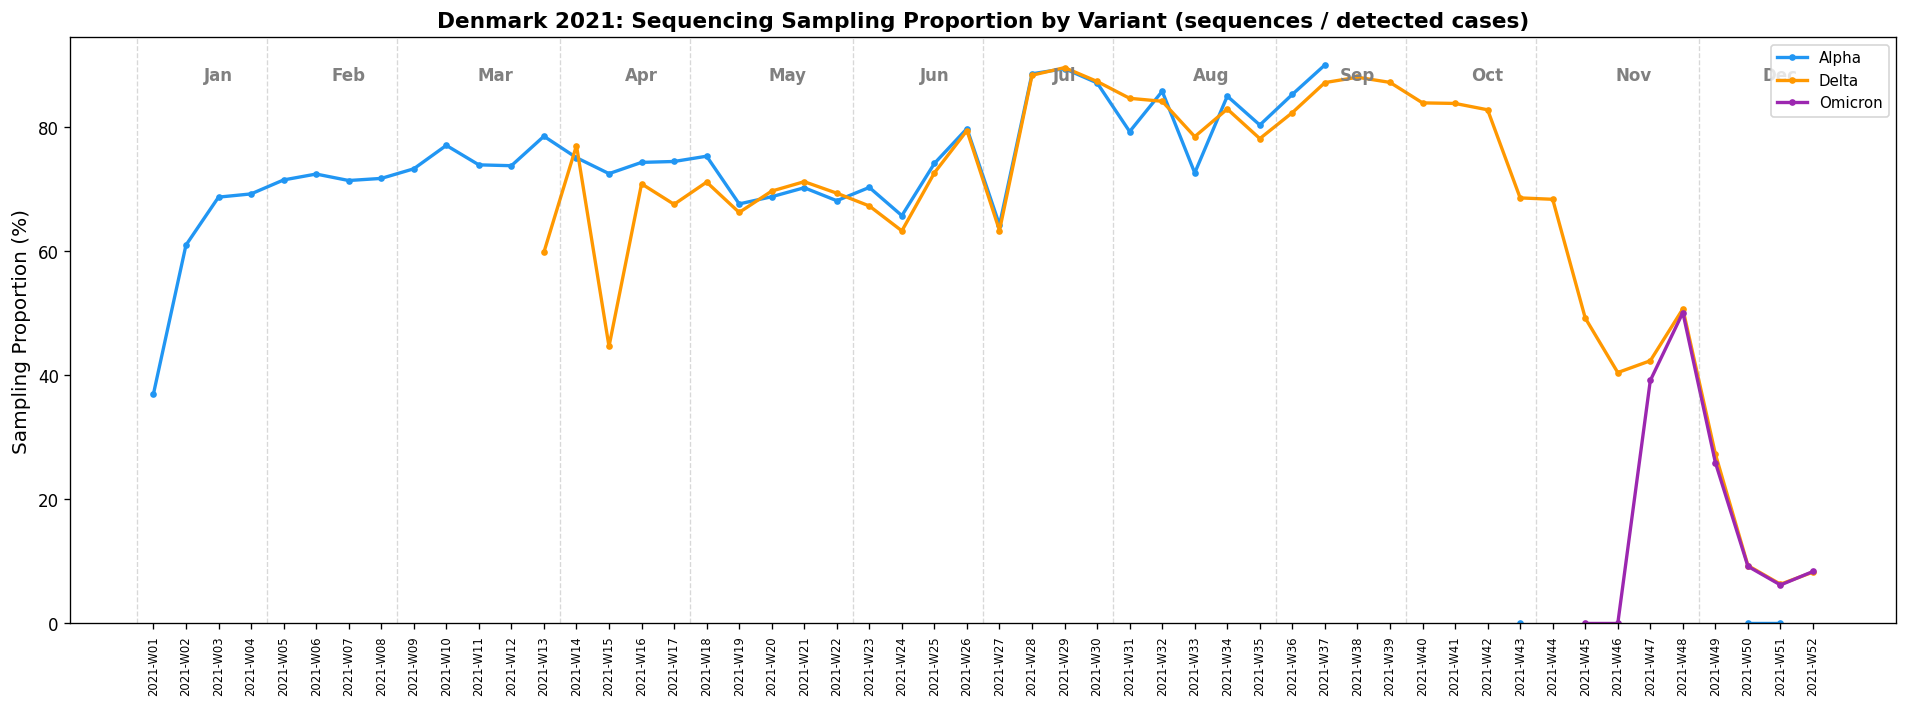

In [6]:
# ── Figure 4: Sampling Proportion by Variant ──

sampling_prop = seq_region_wk[VARIANTS].div(variant_detected[VARIANTS].replace(0, np.nan)) * 100

fig, ax = plt.subplots(figsize=(16, 6))
x = np.arange(len(sampling_prop))
for v in VARIANTS:
    ax.plot(x, sampling_prop[v], color=VARIANT_COLORS[v], marker='o', ms=3, lw=2, label=v)

style_weekly_ax(ax, sampling_prop.index, 'Sampling Proportion (%)',
                'Denmark 2021: Sequencing Sampling Proportion by Variant (sequences / detected cases)')
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(bottom=0)
add_month_labels(ax, w2021['week_start'])

save_and_show(fig, 'denmark_2021_weekly_sampling_proportion.png')

## Subsampling

Downsample the region-filtered GISAID sequences (Fig 3) so that each variant's weekly sampling proportion does not exceed a given baseline. This reduces overrepresentation in heavily-sequenced weeks while preserving under-sampled weeks as-is.

1. **Subsample** — proportional downsampling per variant per epiweek, then compare before/after (Fig 5)
2. **Export** — write subsampled accession lists to CSV
3. **Summary** — time span and sequence counts per variant

In [7]:
SUBSAMPLE_CONFIG = {
    'Alpha':   {'weeks': ('2021-W01', '2021-W22'), 'baseline': 0.08},
    'Delta':   {'weeks': ('2021-W23', '2021-W35'), 'baseline': 0.12},
    'Omicron': {'weeks': ('2021-W45', '2021-W52'), 'baseline': 0.04},
}

RANDOM_SEED = 42

# Precompute valid weeks per variant
valid_weeks = {}
for variant, cfg in SUBSAMPLE_CONFIG.items():
    w_start, w_end = cfg['weeks']
    valid_weeks[variant] = [w for w in w2021.index if w_start <= w <= w_end]

# Subsample: cap sampling proportion (Fig 3 ÷ Fig 2) at baseline per variant per week
rng = np.random.default_rng(RANDOM_SEED)
subsampled_ids = set()

for variant, cfg in SUBSAMPLE_CONFIG.items():
    baseline = cfg['baseline']

    for week in valid_weeks[variant]:
        mask = (seq_records['variant'] == variant) & (seq_records['epiweek'] == week)
        week_seqs = seq_records.loc[mask]
        n_seqs = len(week_seqs)

        n_detected = variant_detected.loc[week, variant]
        if n_detected <= 0 or n_seqs == 0:
            subsampled_ids.update(week_seqs['accession_id'])
            continue

        n_target = int(np.floor(baseline * n_detected))

        if n_seqs > n_target:
            chosen = rng.choice(week_seqs.index, size=n_target, replace=False)
            subsampled_ids.update(week_seqs.loc[chosen, 'accession_id'])
        else:
            subsampled_ids.update(week_seqs['accession_id'])

seq_records['keep'] = seq_records['accession_id'].isin(subsampled_ids)

sub_records = seq_records[seq_records['keep']].copy()
sub_weekly = pivot_to_weekly(sub_records[['date', 'variant', 'epiweek']])

# Before vs after summary
summary_rows = []
for variant, cfg in SUBSAMPLE_CONFIG.items():
    wks = valid_weeks[variant]
    before = seq_region_wk.loc[wks, variant].sum()
    after = sub_weekly.loc[wks, variant].sum()
    w_start, w_end = cfg['weeks']
    summary_rows.append({
        'Variant': variant,
        'Window': f'{w_start}–{w_end}',
        'Baseline': f'{cfg["baseline"]:.0%}',
        'Before': int(before),
        'After': int(after),
        'Reduction': f'{1 - after / before:.1%}' if before > 0 else '—',
    })

print(pd.DataFrame(summary_rows).to_string(index=False))
print(f'\nTotal subsampled sequences: {len(subsampled_ids):,}')

Variant            Window Baseline  Before  After Reduction
  Alpha 2021-W01–2021-W22       8%   57997   6415     88.9%
  Delta 2021-W23–2021-W35      12%   45546   6623     85.5%
Omicron 2021-W45–2021-W52       4%   18221   8584     52.9%

Total subsampled sequences: 21,622


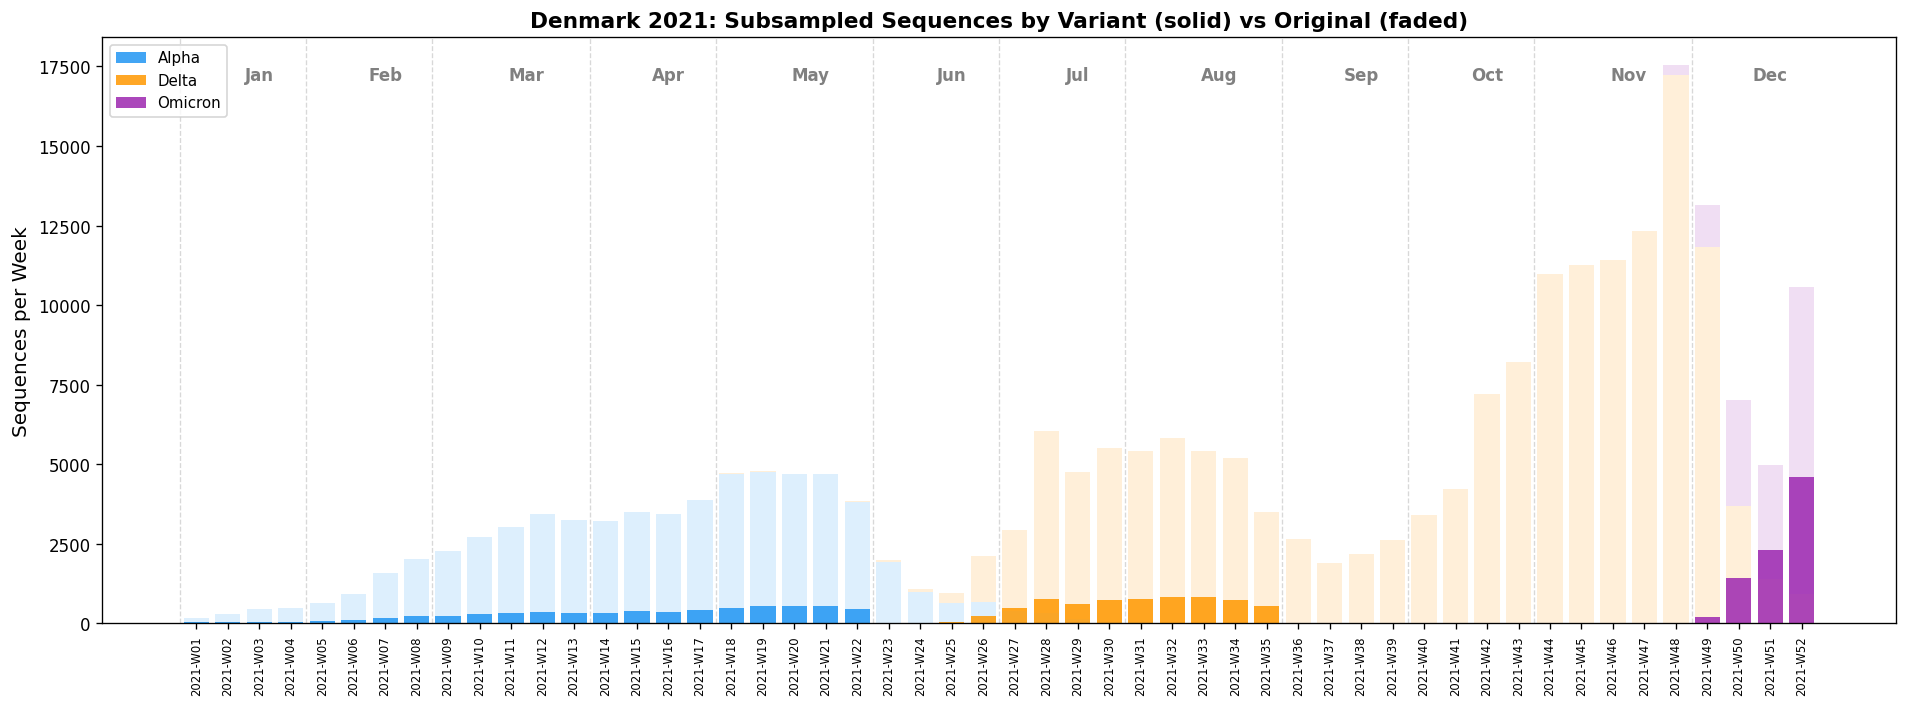

In [8]:
# ── Figure 5: Subsampled Sequences vs Original ──

fig, ax = plt.subplots(figsize=(16, 6))
x = np.arange(len(sub_weekly))

# Original (transparent background) — no labels
bottom_orig = np.zeros(len(seq_region_wk))
for v in VARIANTS:
    vals = seq_region_wk[v].values.astype(float)
    ax.bar(x, vals, bottom=bottom_orig, color=VARIANT_COLORS[v], alpha=0.15)
    bottom_orig += vals

# Subsampled (solid foreground)
plot_stacked_bars(ax, sub_weekly, VARIANTS, VARIANT_COLORS, alpha=0.85)

style_weekly_ax(ax, sub_weekly.index, 'Sequences per Week',
                'Denmark 2021: Subsampled Sequences by Variant (solid) vs Original (faded)')
ax.legend(loc='upper left', fontsize=9)
add_month_labels(ax, w2021['week_start'])

save_and_show(fig, 'denmark_2021_weekly_subsampled.png')

In [9]:
# ── Export subsampled accession IDs + summary ──
# One CSV per variant (accession_id, virus_name, date, epiweek, lineage)
# plus a combined file with all three variants.

export_cols = ['accession_id', 'virus_name', 'date', 'epiweek', 'lineage', 'variant']

for variant, cfg in SUBSAMPLE_CONFIG.items():
    w_start, w_end = cfg['weeks']
    mask = (sub_records['variant'] == variant) & (sub_records['epiweek'] >= w_start) & (sub_records['epiweek'] <= w_end)
    out = sub_records.loc[mask, export_cols].sort_values(['epiweek', 'date'])
    path = os.path.join(NOTEBOOK_DIR, f'subsampled_{variant.lower()}_W{w_start[-2:]}_W{w_end[-2:]}.csv')
    out.to_csv(path, index=False)
    v_dates = out['date']
    print(f'{variant:>7s}: {len(out):>6,} sequences → {path}')
    print(f'         {v_dates.min().date()} → {v_dates.max().date()}  '
          f'({(v_dates.max() - v_dates.min()).days} days)')

# Combined export
combined = sub_records.loc[
    sub_records['variant'].isin(VARIANTS), export_cols
].sort_values(['variant', 'epiweek', 'date'])
combined_path = os.path.join(NOTEBOOK_DIR, 'subsampled_all_variants.csv')
combined.to_csv(combined_path, index=False)
print(f'\nCombined: {len(combined):>6,} sequences → {combined_path}')

# ── Per-week subsampled sequence counts by variant ──
weekly_table = sub_weekly[VARIANTS].copy()
weekly_table.index.name = 'Epiweek'
# Keep only weeks where at least one variant has sequences
weekly_table = weekly_table.loc[weekly_table.sum(axis=1) > 0].astype(int)
weekly_table['Total'] = weekly_table.sum(axis=1)
print(f'\n── Subsampled sequences per epiweek ──')
print(weekly_table.to_string())

  Alpha:  6,415 sequences → /Users/lukelyu/Desktop/GISAID_metadata_2026_03_08/subsampled_alpha_W01_W22.csv
         2021-01-04 → 2021-05-31  (147 days)
  Delta:  6,623 sequences → /Users/lukelyu/Desktop/GISAID_metadata_2026_03_08/subsampled_delta_W23_W35.csv
         2021-06-07 → 2021-09-05  (90 days)
Omicron:  8,584 sequences → /Users/lukelyu/Desktop/GISAID_metadata_2026_03_08/subsampled_omicron_W45_W52.csv
         2021-11-28 → 2022-01-02  (35 days)

Combined: 21,622 sequences → /Users/lukelyu/Desktop/GISAID_metadata_2026_03_08/subsampled_all_variants.csv

── Subsampled sequences per epiweek ──
variant   Alpha  Delta  Omicron  Total
Epiweek                               
2021-W01     33      0        0     33
2021-W02     39      0        0     39
2021-W03     54      0        0     54
2021-W04     55      0        0     55
2021-W05     72      0        0     72
2021-W06    102      0        0    102
2021-W07    177      0        0    177
2021-W08    224      0        0    224
2021-W